# [Workshop] 와인 종류 예측하기
- KNN
- 스케일링

<br/>
<br/>

### 모듈 import
- numpy
- pandas

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

<br/>
<br/>

### 데이터 로드
- `red_wine.csv` 파일을 읽어 `red_wine`에 저장한 후 상위 5개를 출력하세요.
- `white_wine.csv` 파일을 읽어 `white_wine`에 저장한 후 상위 5개를 출력하세요.

In [2]:
# red_wine.csv 읽기
red_wine = pd.read_csv('red_wine.csv')
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# white_wine.csv 읽기
white_wine = pd.read_csv('white_wine.csv')
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


<br/>
<br/>

### 데이터 확인
- `red_wine`과 `white_wine`의 정보를 조회하세요.

In [4]:
# red_wine 정보
red_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
# white_wine 정보
white_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


<br/>
<br/>

### 데이터 범위 확인
- `red_wine`과 `white_wine`의 각 열 별 최대/최소를 출력하세요.
    - `df.agg([함수1, 함수2, 함수3..])`

In [6]:
# red_wine 최대 / 최소
red_wine.agg(['max', 'min'])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
max,15.9,1.58,1.0,15.5,0.611,72.0,289.0,1.00369,4.01,2.00,14.9,8
min,4.6,0.12,0.0,0.9,0.012,1.0,6.0,0.99007,2.74,0.33,8.4,3


In [7]:
# white_wine 최대 / 최소
white_wine.agg(['max', 'min'])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
max,14.2,1.10,1.66,65.8,0.346,289.0,440.0,1.03898,3.82,1.08,14.2,9
min,3.8,0.08,0.00,0.6,0.009,2.0,9.0,0.98711,2.72,0.22,8.0,3


<br/>
<br/>

### 데이터 분류 기준 추가
- `red_wine`에 모든 값이 `red`인 `type` 열을 추가하세요.
- `white_wine`에 모든 값이 `white`인 `type` 열을 추가하세요.

In [8]:
# red_wine에 모든 값이 red인 type 열 추가
red_wine['type'] = 'red'
red_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,red
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,red
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,red
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,red


In [9]:
# white_wine에 모든 값이 white인 type 열 추가
white_wine['type'] = 'white'
white_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6,white
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


<br/>
<br/>

### 데이터 병합
- `red_wine`과 `white_wine`의 컬럼명을 출력하세요.
- `red_wine`과 `white_wine`을 위아래로 결합하여 `wine`에 저장하세요.
- 병합된 `wine` 데이터프레임의 컬럼명을 앞에서부터 순서대로 다음과 같이 변경하세요.
    - '산도', '향', '신선함', '단 맛', '짠 맛', '황 화합물1', '황 화합물2', '무게감', '신 맛', '황 화합물3', '알코올', '품질', '유형'

In [10]:
# red_wine 컬럼명
red_wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')

In [11]:
# white_wine 컬럼명
white_wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')

In [12]:
# 두 데이터프레임 결합
wine = pd.concat([red_wine, white_wine], ignore_index=True)
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [13]:
# wine의 컬럼명 변경
wine.columns = ['산도', '향', '신선함', '단 맛', '짠 맛', '황 화합물1', '황 화합물2', '무게감', '신 맛', '황 화합물3', '알코올', '품질', '유형']
wine

,산도,향,신선함,단 맛,짠 맛,황 화합물1,황 화합물2,무게감,신 맛,황 화합물3,알코올,품질,유형
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


<br/>
<br/>

### 데이터 재확인
 - wine의 정보를 출력하세요.
 - wine의 열 별 결측치를 확인하세요.

In [14]:
# wine의 정보를 출력
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   산도      6497 non-null   float64
 1   향       6497 non-null   float64
 2   신선함     6497 non-null   float64
 3   단 맛     6497 non-null   float64
 4   짠 맛     6497 non-null   float64
 5   황 화합물1  6497 non-null   float64
 6   황 화합물2  6497 non-null   float64
 7   무게감     6497 non-null   float64
 8   신 맛     6497 non-null   float64
 9   황 화합물3  6497 non-null   float64
 10  알코올     6497 non-null   float64
 11  품질      6497 non-null   int64  
 12  유형      6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [15]:
# wine의 열 별 결측치
wine.isna().sum()

산도        0
향         0
신선함       0
단 맛       0
짠 맛       0
황 화합물1    0
황 화합물2    0
무게감       0
신 맛       0
황 화합물3    0
알코올       0
품질        0
유형        0
dtype: int64

<br/>
<br/>

### 데이터 분할
- `wine`을 X와 y로 분리하세요.
    - X: '유형'을 제외한 모든 열
    - y: '유형' 열
- 학습, 검증용 데이터로 분할하세요.
    - 분할 비율은 train 8 : test 2
    - random_state = 0
    - 층화추출(stratify) 적용

In [16]:
# X: '유형'을 제외한 모든 열
X = wine.drop('유형', axis = 1)
X

,산도,향,신선함,단 맛,짠 맛,황 화합물1,황 화합물2,무게감,신 맛,황 화합물3,알코올,품질
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [17]:
# y: '유형' 열
y = wine['유형']
y

0         red
1         red
2         red
3         red
4         red
        ...  
6492    white
6493    white
6494    white
6495    white
6496    white
Name: 유형, Length: 6497, dtype: object

In [18]:
## 학습, 검증용 데이터 분할
# train 8 : test 2
# random_state = 0
# 층화추출(stratify) 적용
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 0,
                                                    stratify = y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5197, 12), (1300, 12), (5197,), (1300,))

<br/>
<br/>

### KNN 모델 학습
- n_neighbors = 5

In [19]:
# KNN 모델 생성 (n_neighbors = 5)
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = 5)
model

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
# 학습용 데이터 학습
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
# 학습, 검증용 데이터의 성능(정확도) 평가
model.score(X_train, y_train), model.score(X_test, y_test)

(0.9588223975370406, 0.9515384615384616)

<br/>
<br/>

### KNN 모델 재학습
- 최소최대 정규화(MinMaxScaler) 적용
- n_neighbors = 5

In [22]:
# X에 MinMaxScaler를 적용하여 변환된 값을 X_scaled에 저장하세요.
from sklearn.preprocessing import MinMaxScaler
X_scaled = MinMaxScaler().fit_transform(X)
X_scaled

array([[0.29752066, 0.41333333, 0.        , ..., 0.19101124, 0.20289855,
        0.33333333],
       [0.33057851, 0.53333333, 0.        , ..., 0.25842697, 0.26086957,
        0.33333333],
       [0.33057851, 0.45333333, 0.02409639, ..., 0.24157303, 0.26086957,
        0.33333333],
       ...,
       [0.2231405 , 0.10666667, 0.11445783, ..., 0.13483146, 0.20289855,
        0.5       ],
       [0.14049587, 0.14      , 0.18072289, ..., 0.08988764, 0.69565217,
        0.66666667],
       [0.18181818, 0.08666667, 0.22891566, ..., 0.05617978, 0.55072464,
        0.5       ]], shape=(6497, 12))

In [23]:
## 학습, 검증용 데이터 분할
# train 8 : test 2
# random_state = 0
# 층화추출(stratify) 적용
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size = 0.2,
                                                    random_state = 0,
                                                    stratify = y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5197, 12), (1300, 12), (5197,), (1300,))

In [24]:
# KNN 모델 생성 (n_neighbors = 5)
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = 5)
model

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
# 학습용 데이터 학습
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
# 학습, 검증용 데이터의 성능(정확도) 평가
model.score(X_train, y_train), model.score(X_test, y_test)

(0.99345776409467, 0.9892307692307692)

<br/>
<br/>

### 하이퍼 파리미터(n_neighbors) 튜닝
- K의 값을 1 ~ 10까지 변경하면서 train 데이터, test 데이터의 score 값을 리스트에 저장하세요.
- 리스트에 저장된 score를 선 그래프로 그리세요.

In [27]:
# K의 값을 1 ~ 10까지 변경하면서 train 데이터, test 데이터의 score 값을 리스트에 저장
train_score = []
test_score = []

for k in range(1, 11) :
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_train, y_train)
    train_score.append(model.score(X_train, y_train))
    test_score.append(model.score(X_test, y_test))
print(train_score)
print(test_score)

[0.9996151625938041, 0.9963440446411391, 0.9959592072349432, 0.9944198576101597, 0.99345776409467, 0.9915335770636906, 0.9924956705791803, 0.9921108331729844, 0.9923032518760824, 0.9921108331729844]
[0.9915384615384616, 0.9876923076923076, 0.9923076923076923, 0.9876923076923076, 0.9892307692307692, 0.9869230769230769, 0.99, 0.9892307692307692, 0.9892307692307692, 0.9884615384615385]


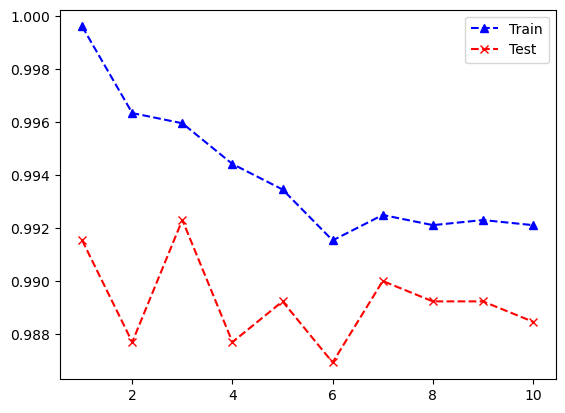

In [28]:
# score 시각화
import matplotlib.pyplot as plt

plt.plot(range(1, 11), train_score, color='blue', linestyle='--', marker='^', label = 'Train')
plt.plot(range(1, 11), test_score, color='red', linestyle='--', marker='x', label = 'Test')
plt.legend()
plt.show()